<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%A0%D0%B5%D0%BA%D1%83%D1%80%D1%80%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B5_%D0%B8_%D0%BE%D0%B4%D0%BD%D0%BE%D0%BC%D0%B5%D1%80%D0%BD%D1%8B%D0%B5_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_%7C_%D0%94%D0%97_Lite_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Из ноутбуков по практике "Рекуррентные и одномерные сверточные нейронные сети" выберите лучшую сеть, либо создайте свою.
2. Запустите раздел "Подготовка"
3. Подготовьте датасет с параметрами `VOCAB_SIZE=20'000`, `WIN_SIZE=1000`, `WIN_HOP=100`, как в ноутбуке занятия, и обучите выбранную сеть. Параметры обучения можно взять из практического занятия. Для  всех обучаемых сетей в данной работе они должны быть одни и теже.
4. Поменяйте размер словаря tokenaizera (`VOCAB_SIZE`) на `5000`, `10000`, `40000`.  Пересоздайте датасеты, при этом оставьте `WIN_SIZE=1000`, `WIN_HOP=100`.
Обучите выбранную нейронку на этих датасетах.  Сделайте выводы об  изменении  точности распознавания авторов текстов. Результаты сведите в таблицу
5. Поменяйте длину отрезка текста и шаг окна разбиения текста на векторы  (`WIN_SIZE`, `WIN_HOP`) используя значения (`500`,`50`) и (`2000`,`200`). Пересоздайте датасеты, при этом оставьте `VOCAB_SIZE=20000`. Обучите выбранную нейронку на этих датасетах. Сделайте выводы об  изменении точности распознавания авторов текстов.

Результаты всей работы сведите в таблицу.

## Подготовка

In [ ]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display
import pandas as pd

%matplotlib inline

In [ ]:
# Загрузим датасет из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [ ]:
# Распакуем архив в папку writers
!unzip -o writers.zip -d writers/


Archive:  writers.zip
  inflating: writers/(Клиффорд_Саймак) Обучающая_5 вместе.txt  
  inflating: writers/(Клиффорд_Саймак) Тестовая_2 вместе.txt  
  inflating: writers/(Макс Фрай) Обучающая_5 вместе.txt  
  inflating: writers/(Макс Фрай) Тестовая_2 вместе.txt  
  inflating: writers/(О. Генри) Обучающая_50 вместе.txt  
  inflating: writers/(О. Генри) Тестовая_20 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Обучающая_22 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Тестовая_8 вместе.txt  
  inflating: writers/(Стругацкие) Обучающая_5 вместе.txt  
  inflating: writers/(Стругацкие) Тестовая_2 вместе.txt  
  inflating: writers/(Булгаков) Обучающая_5 вместе.txt  
  inflating: writers/(Булгаков) Тестовая_2 вместе.txt  


In [ ]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

In [ ]:
# Подготовим пустые списки

CLASS_LIST = []  # Список классов
text_train = []  # Список для оучающей выборки
text_test = []   # Список для тестовой выборки

# Получим списка файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    # Выделяем имя класса и типа выборки из имени файла
    m = re.match('\((.+)\) (\S+)_', file_name)
    # Если выделение получилось, то файл обрабатываем
    if m:

        # Получим имя класса
        class_name = m[1]

        # Получим имя выборки
        subset_name = m[2].lower()

        # Проверим тип выборки
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        # Если тип выборки обучающая либо тестовая - файл обрабатываем
        if is_train or is_test:

            # Добавляем новый класс, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)

                # Инициализируем соответствующих классу строки текста
                text_train.append('')
                text_test.append('')

            # Найдем индекс класса для добавления содержимого файла в выборку
            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')

            # Откроем файл на чтение
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:

                # Загрузим содержимого файла в строку
                text = f.read()
            # Определим выборку, куда будет добавлено содержимое
            subset = text_train if is_train else text_test

            # Добавим текста к соответствующей выборке класса. Концы строк заменяются на пробел
            subset[cls] += ' ' + text.replace('\n', ' ')

Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Тестовая_8 вместе.txt" в класс "Рэй Брэдберри", тестовая выборка.
Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Тестовая_2 вместе.txt" в класс "Стругацкие", тестовая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка.
Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", обучающая выборка.
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка.
Добавление файла "(Стругацкие) Обучающая_5 вместе.

In [ ]:
# Определим количество классов
CLASS_COUNT = len(CLASS_LIST)

In [ ]:
# Выведем прочитанные классы текстов
print(CLASS_LIST)

['Рэй Брэдберри', 'Стругацкие', 'О. Генри', 'Макс Фрай', 'Булгаков', 'Клиффорд_Саймак']


In [ ]:
# Посчитаем количество текстов в обучающей выборке
print(len(text_train))

6


In [ ]:
# Проверим загрузки: выведем начальные отрывки из каждого класса

for cls in range(CLASS_COUNT):                   # Запустим цикл по числу классов
    print(f'Класс: {CLASS_LIST[cls]}')           # Выведем имя класса
    print(f'  train: {text_train[cls][:200]}')   # Выведем фрагмент обучающей выборки
    print(f'  test : {text_test[cls][:200]}')    # Выведем фрагмент тестовой выборки
    print()

Класс: Рэй Брэдберри
  train:  ﻿451° по Фаренгейту   ДОНУ КОНГДОНУ С БЛАГОДАРНОСТЬЮ   Если тебе дадут линованную бумагу, пиши поперёк.  Хуан Рамон Хименес   Часть 1  ОЧАГ И САЛАМАНДРА   Жечь было наслаждением. Какое-то особое насл
  test :  ﻿Марсианские хроники   МОЕЙ ЖЕНЕ МАРГАРЕТ С ИСКРЕННЕЙ ЛЮБОВЬЮ   «Великое дело – способность удивляться, – сказал философ. – Космические полеты снова сделали всех нас детьми».   Январь 1999  Ракетное 

Класс: Стругацкие
  train:  Парень из преисподней     1     Ну и деревня! Сроду я таких деревень не видел и не знал даже, что такие деревни бывают. Дома круглые, бурые, без окон, торчат на сваях, как сторожевые вышки, а под ним
  test :  ﻿ОТЕЛЬ «У ПОГИБШЕГО АЛЬПИНИСТА»    ГЛАВА 1     Я остановил машину, вылез и снял черные очки. Все было так, как рассказывал Згут. Отель был двухэтажный, желтый с зеленым, над крыльцом красовалась трау

Класс: О. Генри
  train:  «Лиса-на-рассвете»   Коралио нежился в полуденном зное, как томная красавица в сурово хранимо

In [ ]:
# Контекстный менеджер для измерения времени операций
# Операция обертывается менеджером с помощью оператора with

class timex:
    def __enter__(self):
        # Фиксация времени старта процесса
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        # Вывод времени работы
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

## Решение

In [ ]:
# ваше решение

# ваше решение
VOCAB_SIZE = 20000                        # Объем словаря для токенизатора
WIN_SIZE   = 1000                         # Длина отрезка текста (окна) в словах
WIN_HOP    = 100                          # Шаг окна разбиения текста на векторы

stat = {'Title': [], VOCAB_SIZE: [VOCAB_SIZE], 'WIN_SIZE': [WIN_SIZE], 'WIN_HOP': [WIN_HOP], 'avg_accuracy': []}
tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                          lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)

# Построение частотного словаря по обучающим текстам
tokenizer.fit_on_texts(text_train)
# Построение словаря в виде пар слово - индекс
items = list(tokenizer.word_index.items())
# Преобразование обучающих и проверочных текстов в последовательность индексов согласно частотному словарю
seq_train = tokenizer.texts_to_sequences(text_train)
seq_test = tokenizer.texts_to_sequences(text_test)



In [ ]:
# Функция разбиения последовательности на отрезки скользящим окном
# На входе - последовательность индексов, размер окна, шаг окна
def split_sequence(sequence, win_size, hop):
    # Последовательность разбивается на части до последнего полного окна
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


# Функция формирования выборок из последовательностей индексов
# формирует выборку отрезков и соответствующих им меток классов в виде one hot encoding
def vectorize_sequence(seq_list, win_size, hop):
    # В списке последовательности следуют в порядке их классов
    # Всего последовательностей в списке ровно столько, сколько классов
    class_count = len(seq_list)

    # Списки для исходных векторов и категориальных меток класса
    x, y = [], []

    # Для каждого класса:
    for cls in range(class_count):
        # Разбиение последовательности класса cls на отрезки
        vectors = split_sequence(seq_list[cls], win_size, hop)
        # Добавление отрезков в выборку
        x += vectors
        # Для всех отрезков класса cls добавление меток класса в виде OHE
        y += [utils.to_categorical(cls, class_count)] * len(vectors)

    # Возврат результатов как numpy-массивов
    return np.array(x), np.array(y)

In [ ]:
 # Формирование обучающей выборки
x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
# Формирование тестовой выборки
x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

# Проверка формы сформированных данных
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(17640, 1000) (17640, 6)
(6686, 1000) (6686, 6)


In [ ]:
# Функция компиляции и обучения модели нейронной сети
def compile_train_model(model,
                        x_train,
                        y_train,
                        x_val,
                        y_val,
                        optimizer='adam',
                        epochs=50,
                        batch_size=128,
                        figsize=(20, 5)):

    # Компиляция модели
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Вывод сводки
    model.summary()

    # Вывод схемы модели
    display(plot_model(model, dpi=60, show_shapes=True))

    # Обучение модели с заданными параметрами
    history = model.fit(x_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val))

    # Вывод графиков точности и ошибки
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='Доля верных ответов на обучающем наборе')
    ax1.plot(history.history['val_accuracy'],
               label='Доля верных ответов на проверочном наборе')
    ax1.xaxis.get_major_locator().set_params(integer=True)
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающем наборе')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочном наборе')
    ax2.xaxis.get_major_locator().set_params(integer=True)
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


# Функция вывода результатов оценки модели на заданных данных
def eval_model(model, x, y_true,
               class_labels=[],
               cm_round=3,
               title='',
               figsize=(10, 10)):
    # Вычисление предсказания сети
    y_pred = model.predict(x)
    # Построение матрицы ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, cm_round)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Нейросеть {title}: матрица ошибок нормализованная', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Стирание ненужной цветовой шкалы
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси при необходимости
    plt.show()

    print('-'*100)
    print(f'Нейросеть: {title}')

    # Для каждого класса:
    for cls in range(len(class_labels)):
        # Определяется индекс класса с максимальным значением предсказания (уверенности)
        cls_pred = np.argmax(cm[cls])
        # Формируется сообщение о верности или неверности предсказания
        msg = 'ВЕРНО :-)' if cls_pred == cls else 'НЕВЕРНО :-('
        # Выводится текстовая информация о предсказанном классе и значении уверенности
        print('Класс: {:<20} {:3.0f}% сеть отнесла к классу {:<20} - {}'.format(class_labels[cls],
                                                                               100. * cm[cls, cls_pred],
                                                                               class_labels[cls_pred],
                                                                               msg))

    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))
    stat['agv_accuracy'].append(100. * cm.diagonal().mean())
    stat['Title'].append(model.title)


# Совместная функция обучения и оценки модели нейронной сети
def compile_train_eval_model(model,
                             x_train,
                             y_train,
                             x_test,
                             y_test,
                             class_labels=CLASS_LIST,
                             title='',
                             optimizer='adam',
                             epochs=50,
                             batch_size=128,
                             graph_size=(20, 5),
                             cm_size=(10, 10)):

    # Компиляция и обучение модели на заданных параметрах
    # В качестве проверочных используются тестовые данные
    compile_train_model(model,
                        x_train, y_train,
                        x_test, y_test,
                        optimizer=optimizer,
                        epochs=epochs,
                        batch_size=batch_size,
                        figsize=graph_size)

    # Вывод результатов оценки работы модели на тестовых данных
    eval_model(model, x_test, y_test,
               class_labels=class_labels,
               title=title,
               figsize=cm_size)

In [ ]:
model = Sequential()
model.add(Embedding(VOCAB_SIZE, 50, input_length=WIN_SIZE))
model.add(SpatialDropout1D(0.4))
model.add(BatchNormalization())
# Два двунаправленных рекуррентных слоя LSTM
model.add(Bidirectional(LSTM(8, return_sequences=True)))
model.add(Bidirectional(LSTM(8, return_sequences=True)))
model.add(Dropout(0.3))
model.add(BatchNormalization())
# Два рекуррентных слоя GRU
model.add(GRU(16, return_sequences=True, reset_after=True))
model.add(GRU(16, reset_after=True))
model.add(Dropout(0.3))
model.add(BatchNormalization())
# Дополнительный полносвязный слой
model.add(Dense(200, activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())
model.add(Dense(CLASS_COUNT, activation='softmax'))
model.build()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_1                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_3 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

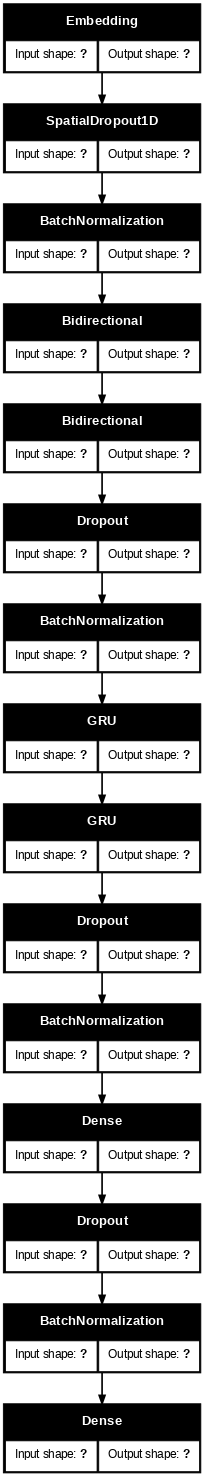

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 297ms/step - accuracy: 0.1956 - loss: 2.1515 - val_accuracy: 0.2929 - val_loss: 1.7443
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 275ms/step - accuracy: 0.3119 - loss: 1.7904 - val_accuracy: 0.2929 - val_loss: 1.7521
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.4018 - loss: 1.5554 - val_accuracy: 0.3012 - val_loss: 1.6927
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 307ms/step - accuracy: 0.5076 - loss: 1.2763 - val_accuracy: 0.2130 - val_loss: 1.8818
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 268ms/step - accuracy: 0.6058 - loss: 1.0221 - val_accuracy: 0.0918 - val_loss: 2.2623
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - accuracy: 0.6961 - loss: 0.7920 - val_accuracy: 0.1324 - val_loss: 2.7469
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.7522 - loss: 0.6478 - val_accuracy: 0.1813 - val_loss: 3.3401
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 273ms/step - accuracy: 0.8053 - loss: 0.5116 - va

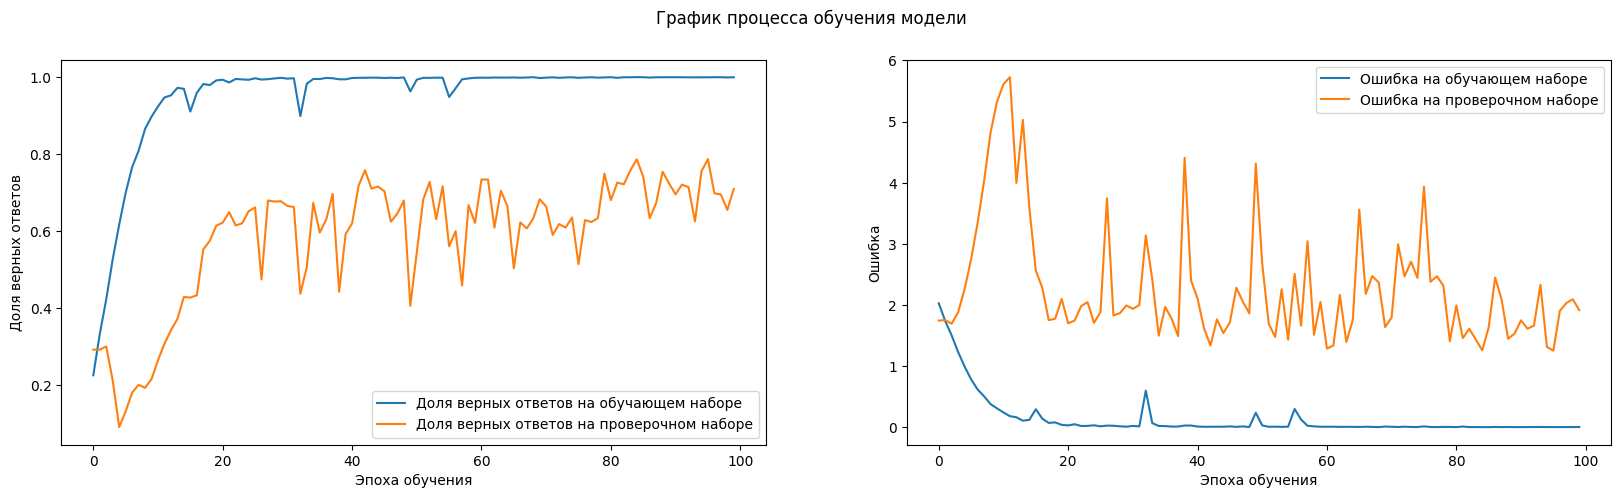

209/209 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step


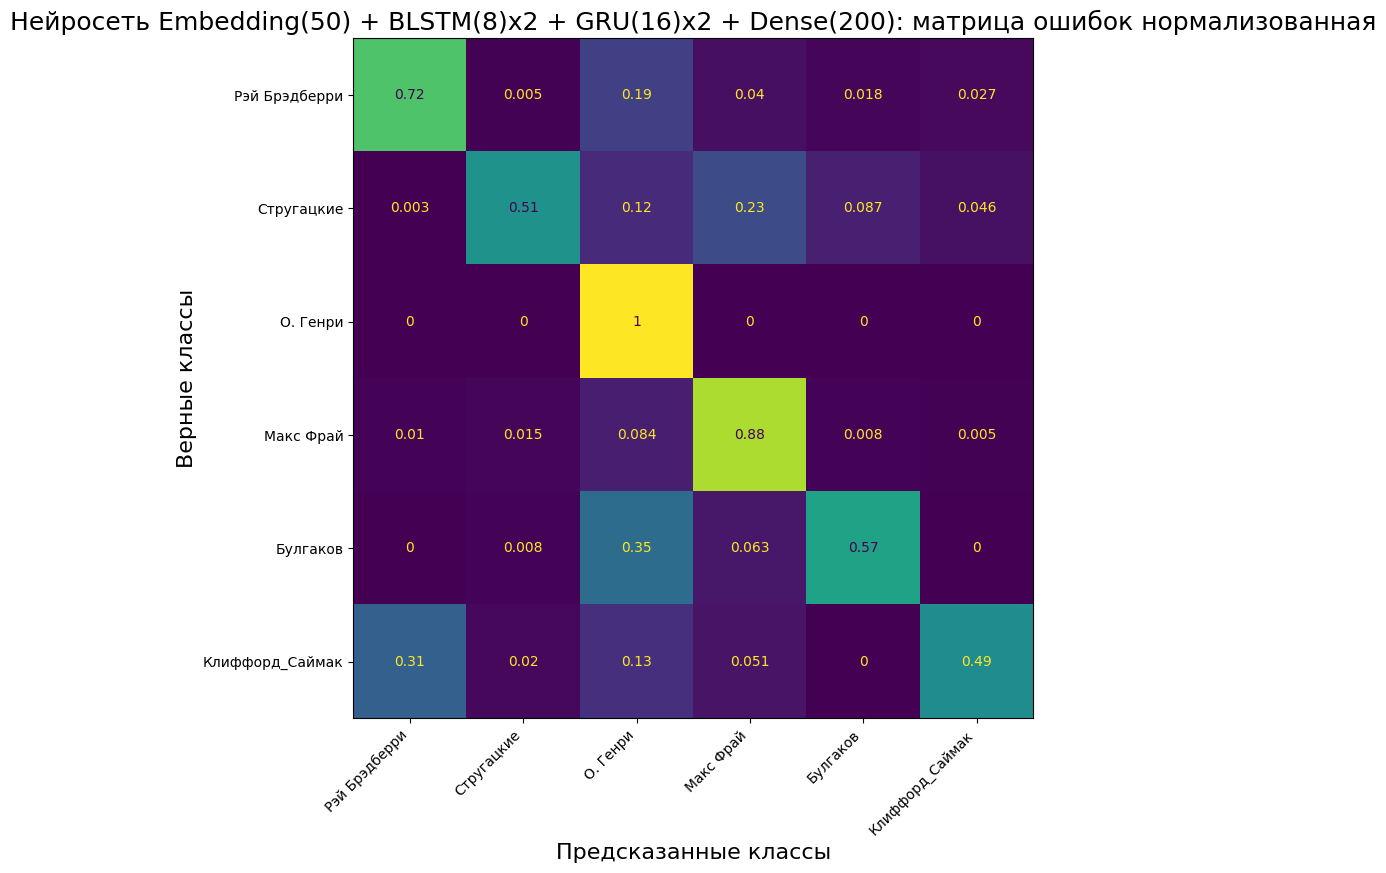

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)
Класс: Рэй Брэдберри         72% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            51% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: О. Генри             100% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Макс Фрай             88% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Булгаков              57% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: Клиффорд_Саймак       49% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)

Средняя точность распознавания:  70%


In [ ]:
compile_train_eval_model(model,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)')

(17640, 1000) (17640, 6)
(6686, 1000) (6686, 6)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_3                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_6 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_7 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_6 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_7 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

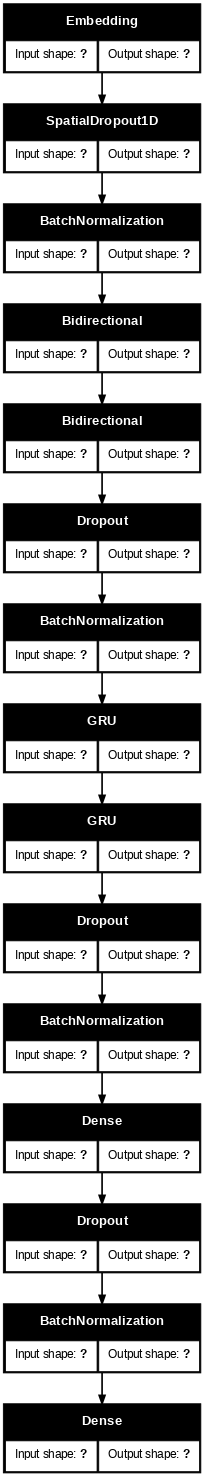

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 308ms/step - accuracy: 0.1905 - loss: 2.1707 - val_accuracy: 0.2929 - val_loss: 1.7386
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 276ms/step - accuracy: 0.2963 - loss: 1.8035 - val_accuracy: 0.2929 - val_loss: 1.7438
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 277ms/step - accuracy: 0.3895 - loss: 1.6005 - val_accuracy: 0.2538 - val_loss: 1.7573
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 316ms/step - accuracy: 0.4719 - loss: 1.3641 - val_accuracy: 0.1611 - val_loss: 1.8577
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 269ms/step - accuracy: 0.5280 - loss: 1.2021 - val_accuracy: 0.1611 - val_loss: 1.9552
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 305ms/step - accuracy: 0.3080 - loss: 1.8297 - val_accuracy: 0.2929 - val_loss: 1.7857
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 280ms/step - accuracy: 0.3774 - loss: 1.5799 - val_accuracy: 0.1971 - val_loss: 1.7296
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 319ms/step - accuracy: 0.4803 - loss: 1.3267 - 

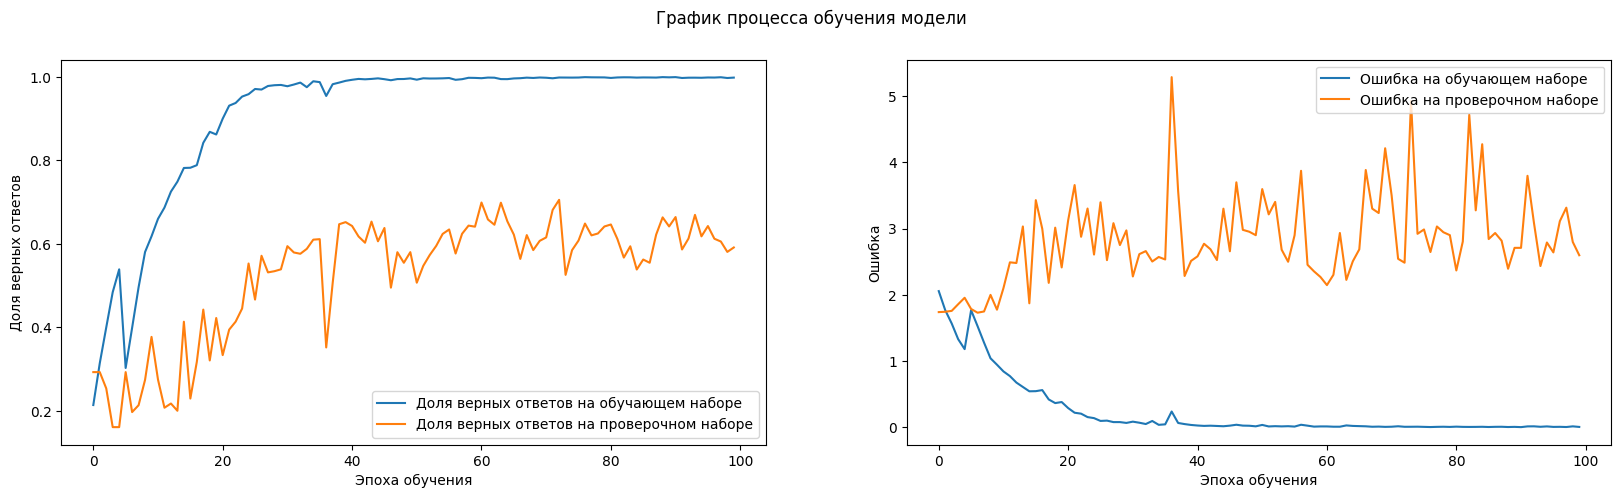

209/209 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step


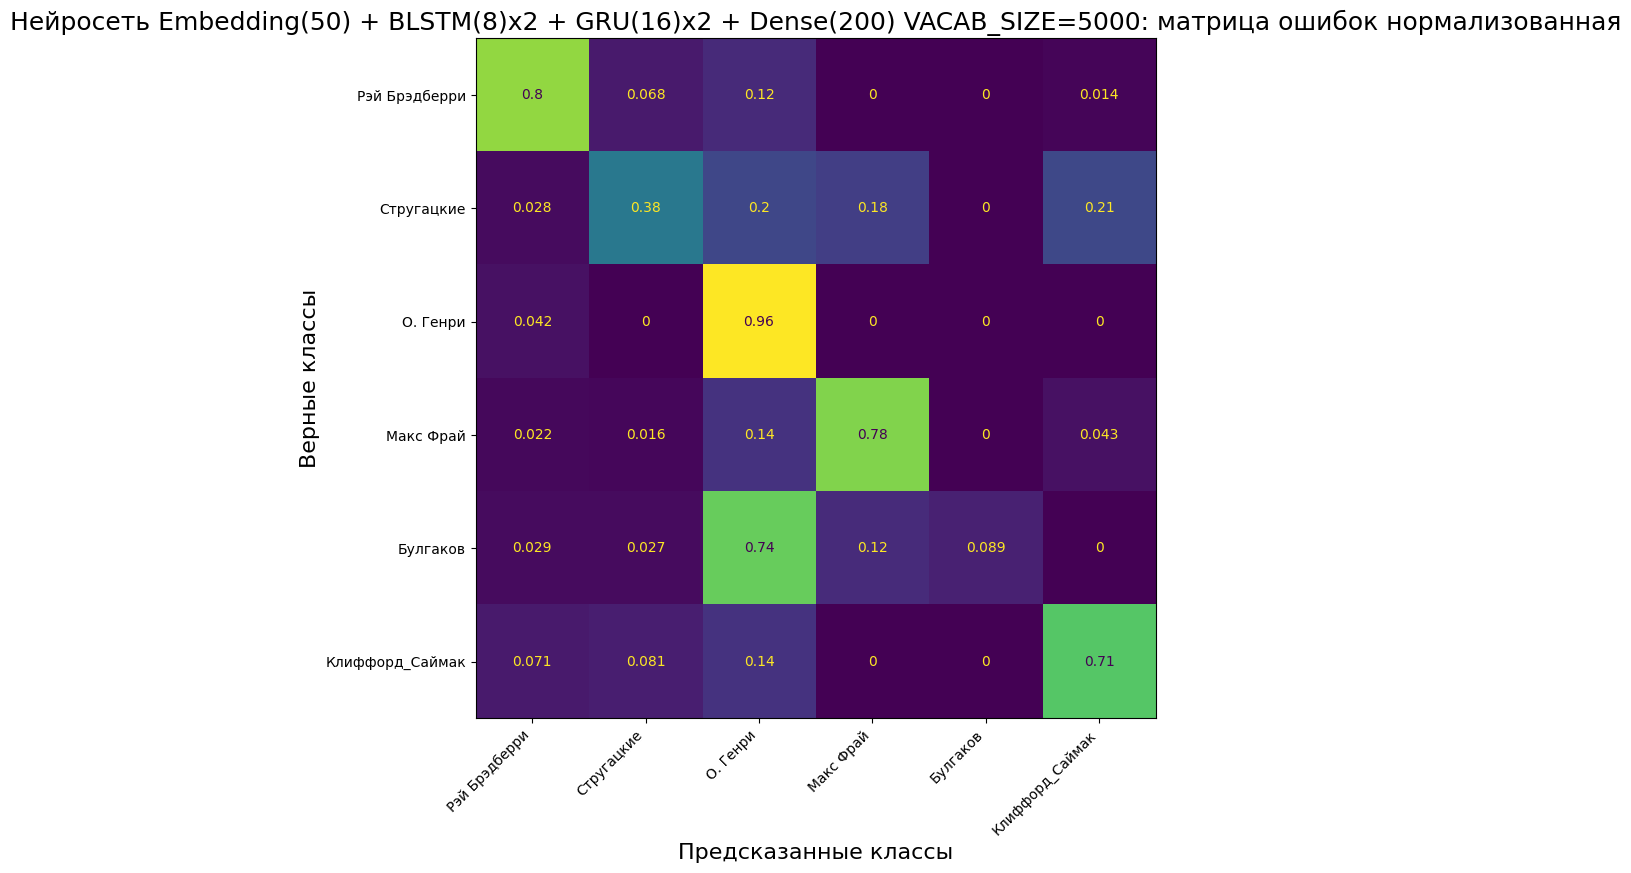

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200) VACAB_SIZE=5000
Класс: Рэй Брэдберри         80% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            38% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: О. Генри              96% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Макс Фрай             78% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Булгаков              74% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       71% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)

Средняя точность распознавания:  62%
(17640, 1000) (17640, 6)
(6686, 1000) (6686, 6)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_4                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_8 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_9 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_8 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_9 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

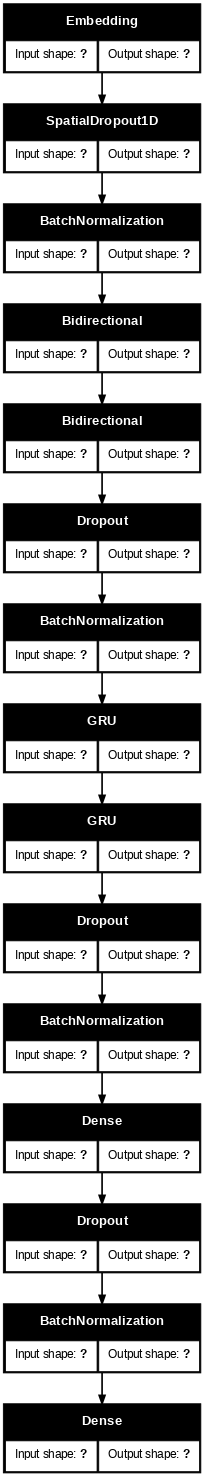

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 297ms/step - accuracy: 0.1935 - loss: 2.1433 - val_accuracy: 0.2929 - val_loss: 1.7380
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 281ms/step - accuracy: 0.2854 - loss: 1.8610 - val_accuracy: 0.2929 - val_loss: 1.7436
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 277ms/step - accuracy: 0.3722 - loss: 1.6429 - val_accuracy: 0.2929 - val_loss: 1.7630
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 283ms/step - accuracy: 0.4579 - loss: 1.4113 - val_accuracy: 0.2929 - val_loss: 1.8582
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 277ms/step - accuracy: 0.5470 - loss: 1.1565 - val_accuracy: 0.3199 - val_loss: 1.6748
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 312ms/step - accuracy: 0.6200 - loss: 0.9544 - val_accuracy: 0.2929 - val_loss: 3.6012
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 275ms/step - accuracy: 0.6732 - loss: 0.8372 - val_accuracy: 0.2771 - val_loss: 1.9604
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.7222 - loss: 0.7046 - 

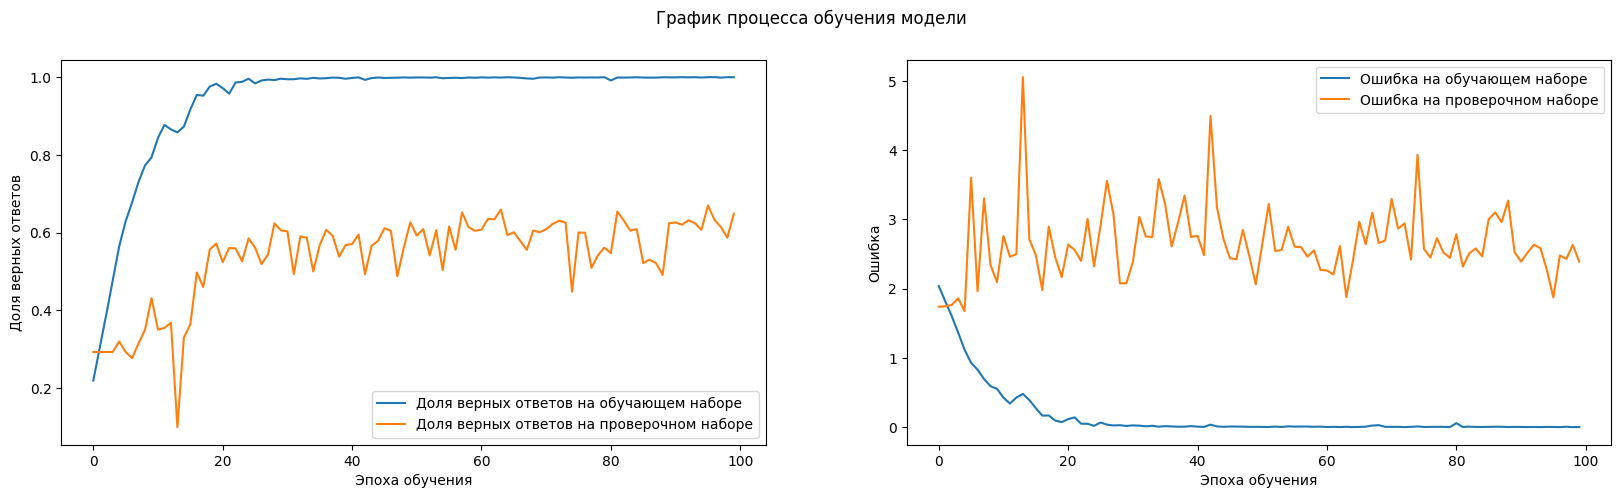

209/209 ━━━━━━━━━━━━━━━━━━━━ 15s 68ms/step


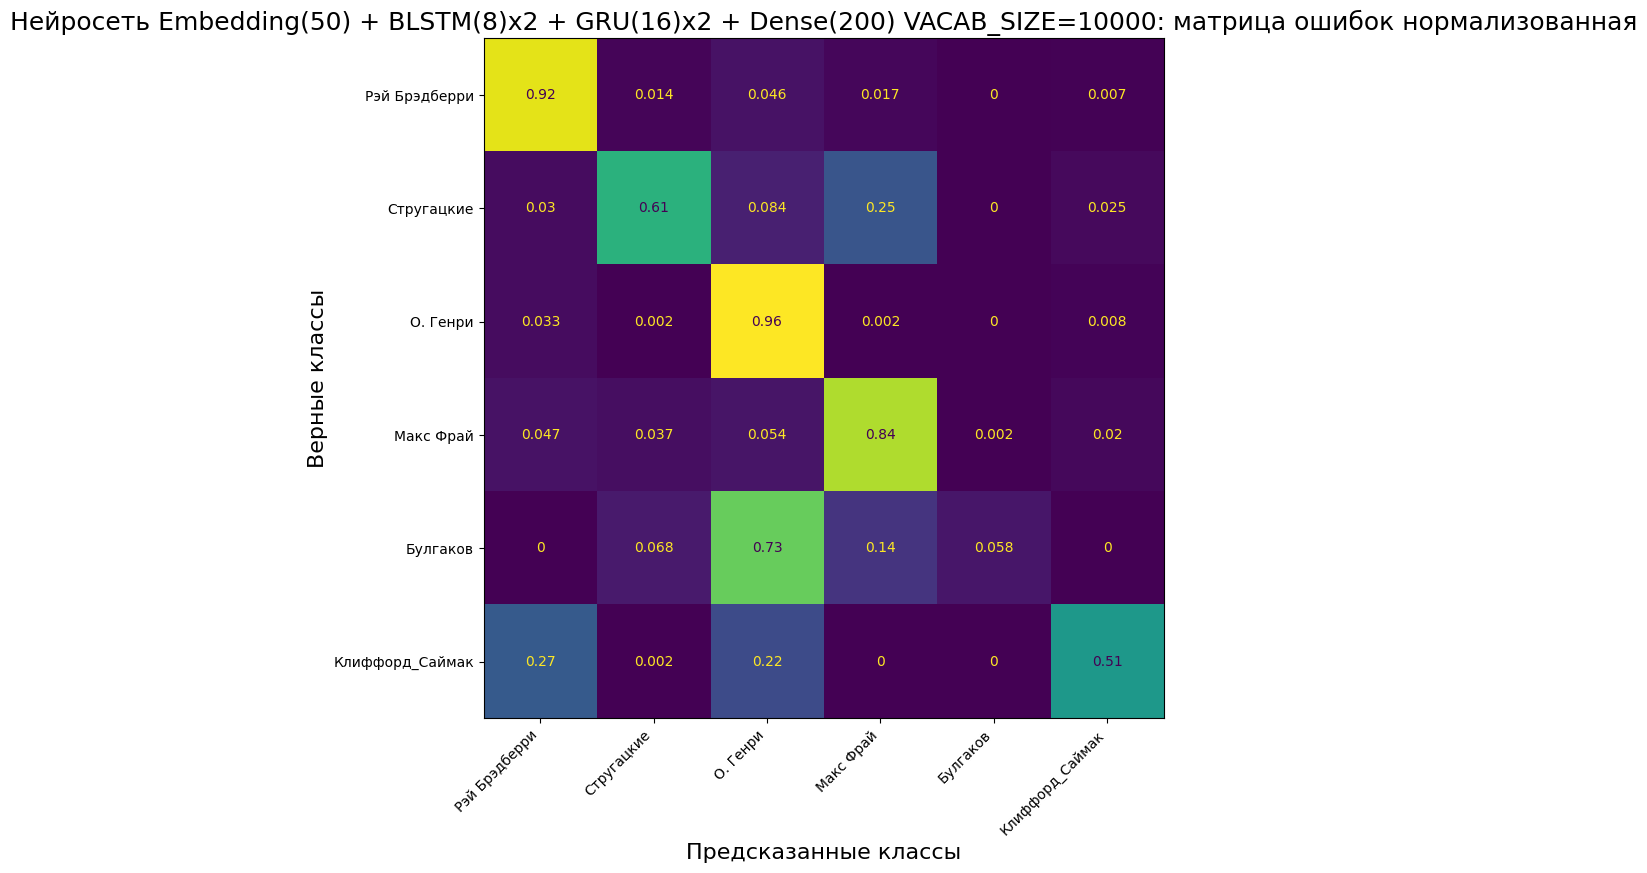

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200) VACAB_SIZE=10000
Класс: Рэй Брэдберри         92% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            61% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: О. Генри              96% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Макс Фрай             84% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Булгаков              73% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       51% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)

Средняя точность распознавания:  65%
(17640, 1000) (17640, 6)
(6686, 1000) (6686, 6)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_5                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_10 (Bidirectional)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_11 (Bidirectional)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_10 (GRU)                         │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_11 (GRU)                         │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_22               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_23               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

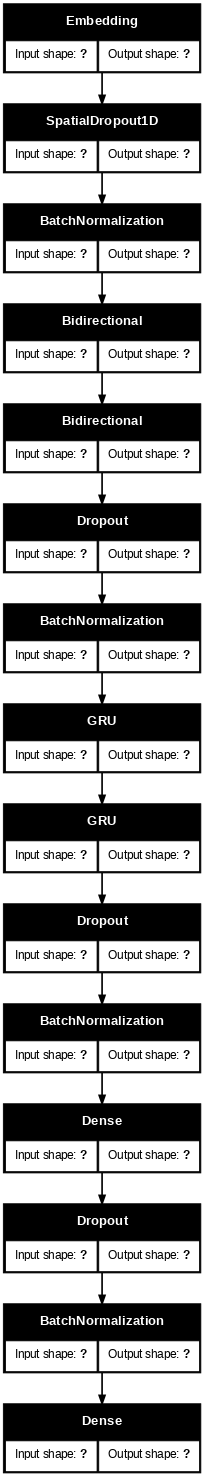

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 296ms/step - accuracy: 0.1888 - loss: 2.1453 - val_accuracy: 0.2929 - val_loss: 1.7357
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 276ms/step - accuracy: 0.2999 - loss: 1.8127 - val_accuracy: 0.2929 - val_loss: 1.7358
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 284ms/step - accuracy: 0.3909 - loss: 1.5831 - val_accuracy: 0.1611 - val_loss: 1.7834
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 280ms/step - accuracy: 0.4743 - loss: 1.3394 - val_accuracy: 0.1561 - val_loss: 1.8937
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 275ms/step - accuracy: 0.5536 - loss: 1.1197 - val_accuracy: 0.2499 - val_loss: 1.8153
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 277ms/step - accuracy: 0.6475 - loss: 0.8967 - val_accuracy: 0.2789 - val_loss: 1.9070
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.7289 - loss: 0.7032 - val_accuracy: 0.3714 - val_loss: 1.7356
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 280ms/step - accuracy: 0.8027 - loss: 0.5478 - 

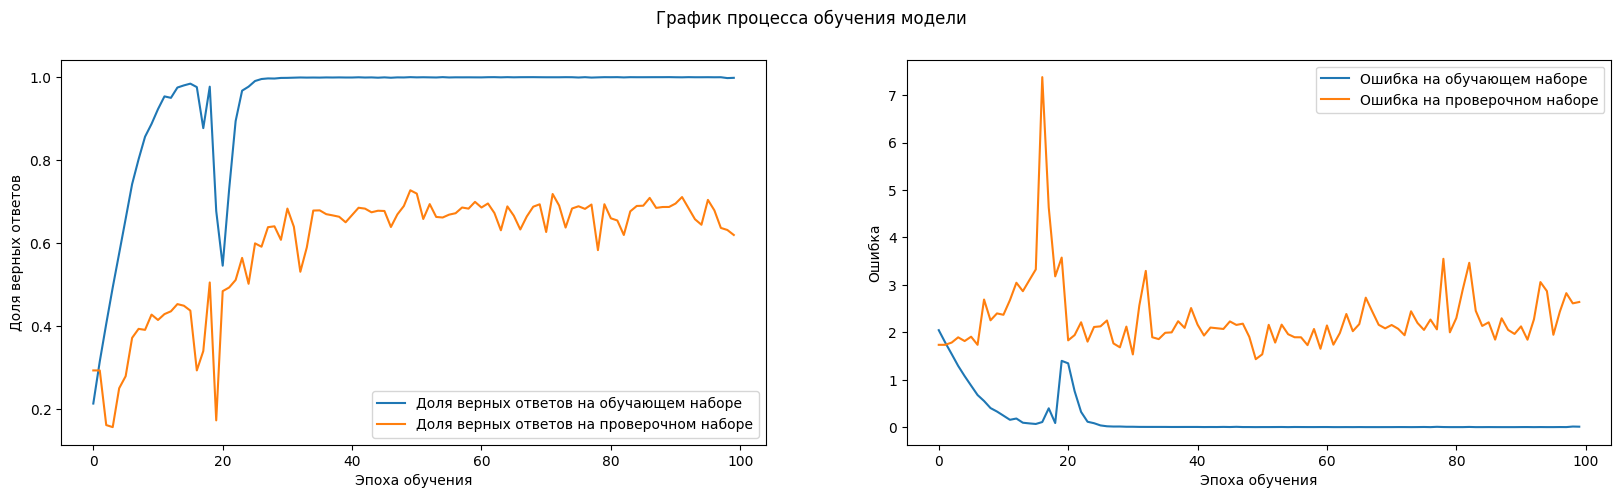

209/209 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step


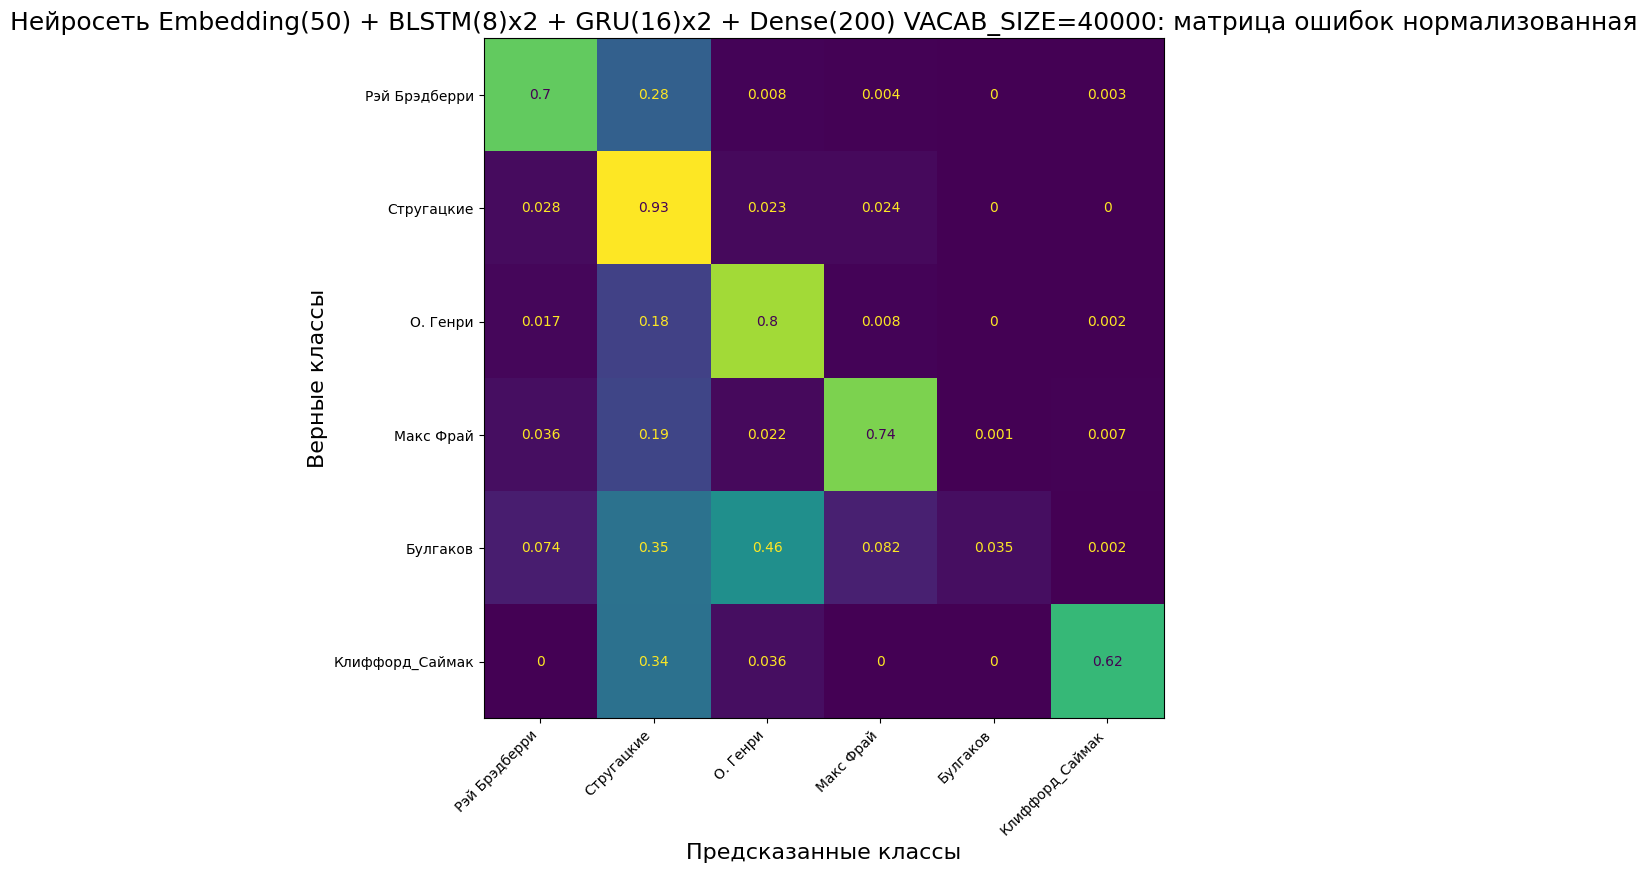

----------------------------------------------------------------------------------------------------
Нейросеть: Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200) VACAB_SIZE=40000
Класс: Рэй Брэдберри         70% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Стругацкие            92% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: О. Генри              80% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Макс Фрай             74% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Булгаков              46% сеть отнесла к классу О. Генри             - НЕВЕРНО :-(
Класс: Клиффорд_Саймак       62% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)

Средняя точность распознавания:  64%


In [ ]:
WIN_SIZE   = 1000                         # Длина отрезка текста (окна) в словах
WIN_HOP    = 100                          # Шаг окна разбиения текста на векторы
for VOCAB_SIZE in [5000, 10000, 40000]: # Объем словаря для токенизатора
  tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                            lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)

  # Построение частотного словаря по обучающим текстам
  tokenizer.fit_on_texts(text_train)
  # Построение словаря в виде пар слово - индекс
  items = list(tokenizer.word_index.items())
  # Преобразование обучающих и проверочных текстов в последовательность индексов согласно частотному словарю
  seq_train = tokenizer.texts_to_sequences(text_train)
  seq_test = tokenizer.texts_to_sequences(text_test)
 # Формирование обучающей выборки
  x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
  # Формирование тестовой выборки
  x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

  # Проверка формы сформированных данных
  print(x_train.shape, y_train.shape)
  print(x_test.shape, y_test.shape)

  model = Sequential()
  model.add(Embedding(VOCAB_SIZE, 50, input_length=WIN_SIZE))
  model.add(SpatialDropout1D(0.4))
  model.add(BatchNormalization())
  # Два двунаправленных рекуррентных слоя LSTM
  model.add(Bidirectional(LSTM(8, return_sequences=True)))
  model.add(Bidirectional(LSTM(8, return_sequences=True)))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  # Два рекуррентных слоя GRU
  model.add(GRU(16, return_sequences=True, reset_after=True))
  model.add(GRU(16, reset_after=True))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  # Дополнительный полносвязный слой
  model.add(Dense(200, activation='relu'))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  model.add(Dense(CLASS_COUNT, activation='softmax'))
  model.build()
  compile_train_eval_model(model,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title='Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200) VACAB_SIZE=' + str(VOCAB_SIZE))





In [ ]:
VOCAB_SIZE = 20000                        # Объем словаря для токенизатора
for WIN_SIZE,WIN_HOP in ((500, 50), (2000, 200)):
  tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                            lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)

  # Построение частотного словаря по обучающим текстам
  tokenizer.fit_on_texts(text_train)
  # Построение словаря в виде пар слово - индекс
  items = list(tokenizer.word_index.items())
  # Преобразование обучающих и проверочных текстов в последовательность индексов согласно частотному словарю
  seq_train = tokenizer.texts_to_sequences(text_train)
  seq_test = tokenizer.texts_to_sequences(text_test)
 # Формирование обучающей выборки
  x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
  # Формирование тестовой выборки
  x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

  # Проверка формы сформированных данных
  print(x_train.shape, y_train.shape)
  print(x_test.shape, y_test.shape)

  model = Sequential()
  model.add(Embedding(VOCAB_SIZE, 50, input_length=WIN_SIZE))
  model.add(SpatialDropout1D(0.4))
  model.add(BatchNormalization())
  # Два двунаправленных рекуррентных слоя LSTM
  model.add(Bidirectional(LSTM(8, return_sequences=True)))
  model.add(Bidirectional(LSTM(8, return_sequences=True)))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  # Два рекуррентных слоя GRU
  model.add(GRU(16, return_sequences=True, reset_after=True))
  model.add(GRU(16, reset_after=True))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  # Дополнительный полносвязный слой
  model.add(Dense(200, activation='relu'))
  model.add(Dropout(0.3))
  model.add(BatchNormalization())
  model.add(Dense(CLASS_COUNT, activation='softmax'))
  model.build()
  compile_train_eval_model(model,
                         x_train, y_train,
                         x_test, y_test,
                         optimizer='rmsprop',
                         epochs=100,
                         batch_size=512,
                         class_labels=CLASS_LIST,
                         title=f'Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200) WIN_SIZE={WIN_SIZE}, WIN_HOP={WIN_HOP}')